<a href="https://colab.research.google.com/github/Parthav47/llm_calling/blob/main/Production_Ready_GenAI_%26_Responsible_AI_Basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stream Summarizer

In [ ]:
!pip install groq -q
import time
from groq import Groq
#import getpass
from google.colab import userdata

client = Groq(api_key=userdata.get("GROQ_API_KEY"))
model="llama-3.3-70b-versatile"


def stream_summarizer(text):
  print("---AI Summary---")

  try:
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role":"user","content":f"Summarize this brief and precise within 100 words on this:{text}"}
        ],
        stream=True
    )

    full_response=""
    for chunk in response:
      delta  = chunk.choices[0].delta.content
      if  delta:
        print(delta,end="",flush=True)
        full_response+=delta
    print("\n")
    print("="*30)
    print("TOKEN USAGE STATUS")
    print(f"Prompt Token:{chunk.usage.prompt_tokens}")
    print(f"Completion Token:{chunk.usage.completion_tokens}")
    print(f"Total Token:{chunk.usage.total_tokens}")
    print("="*30)
  except Exception as e:
    print(f"Error:{e}")

#test
test = """Andy Weir’s Project Hail Mary is a high-stakes, hard science fiction masterpiece that blends rigorous scientific realism with a deeply human—and non-human—emotional core.
The story follows Ryland Grace, a middle-school science teacher who wakes up on a starship with no memory of his name, his mission, or why his two crewmates are dead.
 As his amnesia clears through a series of vivid flashbacks, Grace remembers that he is Earth’s last hope. A microscopic organism called "Astrophage" is consuming the sun’s energy at an exponential rate,
 threatening to trigger a global ice age and total extinction. Tasked with finding a solution in a distant star system, Grace must use his scientific ingenuity to survive the vacuum of space and the complexities of interstellar physics.
The narrative takes a transformative turn when Grace encounters an alien vessel piloted by "Rocky," a spider-like engineer from the Eridani system whose home planet is facing the exact same catastrophe.
What begins as a lonely survival tale evolves into one of the most celebrated "first contact" stories in modern literature. Despite their vast biological differences—Rocky breathes ammonia and communicates through musical chords—the two
develop a profound bond built on mutual respect and shared curiosity. Through a process of trial and error, they translate their languages and combine their unique scientific perspectives to save both their civilizations. The novel is a testament
to the power of collaboration, sacrificing one’s safety for the greater good, and the idea that science is a universal language that can bridge the gap between even the most alien of worlds."""
stream_summarizer(test)


---AI Summary---
Andy Weir's Project Hail Mary is a hard science fiction novel about Ryland Grace, a science teacher who wakes up on a starship with amnesia. As his memories return, he recalls his mission to save Earth from an energy-consuming organism. He encounters an alien, "Rocky," and they form a bond, combining their scientific knowledge to save both their worlds from extinction. The novel celebrates collaboration, sacrifice, and the universal language of science, bridging the gap between humanity and an alien world. It's a high-stakes, emotional, and transformative tale of first contact.

TOKEN USAGE STATUS
Prompt Token:372
Completion Token:120
Total Token:492


In [ ]:
!pip install --upgrade groq

In [4]:
#Updated with exponential backoff

!pip install groq -q
import time
import groq
from groq import Groq
from google.colab import userdata

client = Groq(api_key=userdata.get("GROQ_API_KEY"))
model="llama-3.3-70b-versatile"


def stream_summarizer(text,max_retries=3):
  retries = 0
  backoff_time= 2

  print("---AI Summary---")
  while retries < max_retries:
    try:
      response = client.chat.completions.create(
          model=model,
          messages=[
            {"role":"user","content":f"Summarize this brief and precise within 100 words on this:{text}"}
          ],
          stream=True
      )

      for chunk in response:
        if chunk.choices and chunk.choices[0].delta.content:
          print(chunk.choices[0].delta.content,end="",flush=True)
        if chunk.usage:
          print(f"\nPrompt: {chunk.usage.prompt_tokens} \t Completion: {chunk.usage.completion_tokens}")
          print(f"\n Token Used:{chunk.usage.total_tokens}")

      return
    except groq.RateLimitError as e:
      retries+=1;
      if (retries==max_retries):
        print(f"max retries reached:{e}")
        break
      else:
        time.sleep(backoff_time)
        backoff_time*=2

    except groq.APIStatuserror as e:
      print(f"Groq Server Error: {e.status_code}")

    except Exception as e:
      print(f"Error:{e}")
      break

#test
test = """Andy Weir’s Project Hail Mary is a high-stakes, hard science fiction masterpiece that blends rigorous scientific realism with a deeply human—and non-human—emotional core.
The story follows Ryland Grace, a middle-school science teacher who wakes up on a starship with no memory of his name, his mission, or why his two crewmates are dead.
 As his amnesia clears through a series of vivid flashbacks, Grace remembers that he is Earth’s last hope. A microscopic organism called "Astrophage" is consuming the sun’s energy at an exponential rate,
 threatening to trigger a global ice age and total extinction. Tasked with finding a solution in a distant star system, Grace must use his scientific ingenuity to survive the vacuum of space and the complexities of interstellar physics.
The narrative takes a transformative turn when Grace encounters an alien vessel piloted by "Rocky," a spider-like engineer from the Eridani system whose home planet is facing the exact same catastrophe.
What begins as a lonely survival tale evolves into one of the most celebrated "first contact" stories in modern literature. Despite their vast biological differences—Rocky breathes ammonia and communicates through musical chords—the two
develop a profound bond built on mutual respect and shared curiosity. Through a process of trial and error, they translate their languages and combine their unique scientific perspectives to save both their civilizations. The novel is a testament
to the power of collaboration, sacrificing one’s safety for the greater good, and the idea that science is a universal language that can bridge the gap between even the most alien of worlds."""
stream_summarizer(test)


---AI Summary---
Andy Weir's Project Hail Mary is a science fiction novel about Ryland Grace, a science teacher who wakes up on a starship with amnesia. As his memories return, he must find a solution to save Earth from an organism consuming the sun's energy. He encounters an alien, "Rocky," and together they form a bond, combining their scientific knowledge to save both their civilizations from extinction, showcasing the power of collaboration and science as a universal language.
Prompt: 369 	 Completion: 95

 Token Used:464


# Hallucinations and Responsible AI Updates

In [19]:
# llm_output scraper

import json
import re

def parse_llm_output(llm_output):
  try:
    match = re.search(r'\{.*\}', llm_output, re.DOTALL)

    if match:
      json_str = match.group(0)
      return json.loads(json_str)
    else:
      return {"error":f"No json braces found in output: {llm_output}"}
  except Exception as e:
    return {"error":f"Invalid json format: {str(e)}, raw output: {llm_output}"}

test = " fbkrkk {\"score\":1,\"haullicination_found\":true,\"reason\":\"The Great Wall of China is not visible from the moon with the naked eye, as it is only about 30 feet wide and blends in with the Earth's surface from space.\"} blidj"
result = parse_llm_output(test)
print(result)

{'score': 1, 'haullicination_found': True, 'reason': "The Great Wall of China is not visible from the moon with the naked eye, as it is only about 30 feet wide and blends in with the Earth's surface from space."}


In [23]:
# Implemented fact-checker
# Resolve bug issue
import time
import json

def grounded_summarizer(url_text):
    print("\n--- Phase 1: Generating Initial Summary ---")

    # Task A: Grounding the prompt
    initial_prompt = f"""
    Summarize the text below.
    STRICT RULE: Use ONLY the provided text.
    If you cannot find a fact, do not make it up.
    If the text is empty or unclear, say "Insufficient data."

    Text: {url_text}
    """

    summary = stream_summarizer(initial_prompt)

    print("\n--- Phase 2: Fact-Checking Layer ---")
    time.sleep(2)

    fact_check_prompt = f"""
    You are a professional fact-checker.
    Original Text: {url_text}
    Generated Summary: {summary}

    Check for the facts ONLY not in the source. Return the output ONLY in json.
    JSON:{{"score":<1-10>,"haullicination_found":<bool>,"reason":"<string>"}}
    """
    #{{...}} is used to differentiate the json format form the f"..." format
    # Using quotations, specifying data types need to be proper or else llm will mirror it in output

    final_json_summary = stream_summarizer(fact_check_prompt)

    try:
      #judge_raw= json.loads(final_json_summary.strip("`").replace("json",""))
      # Use the robust regex-based parser we discussed
        judge_raw = parse_llm_output(final_json_summary)

        # Use .get() to safely access keys
        score = judge_raw.get("score")

        if score is not None and int(score) >= 8:
            print(f"\nPassed: Score {score}")
            print(f"Final Summary: {summary}")
        elif score is not None:
            print(f"\nRejected: Score {score}")
            print(f"Reason: {judge_raw.get('reason', 'No reason provided')}")
        else:
            print(f"\nCould not find a score in the auditor output.")
    except Exception as e:
      print(f"Error:{e}")

# Test with a snippet
sample_text = "The Great Wall of China is visible from the moon with the naked eye."
grounded_summarizer(sample_text)


--- Phase 1: Generating Initial Summary ---
---AI Summary---
The text states that the Great Wall of China is visible from the moon with the naked eye.
Prompt: 115 	 Completion: 20

 Token Used:135

--- Phase 2: Fact-Checking Layer ---
---AI Summary---
{"score":1,"haullicination_found":true,"reason":"The Great Wall of China is not visible from the moon with the naked eye, it's a common myth debunked by astronauts and satellite images."}
Prompt: 130 	 Completion: 45

 Token Used:175

Could not find a score in the auditor output.


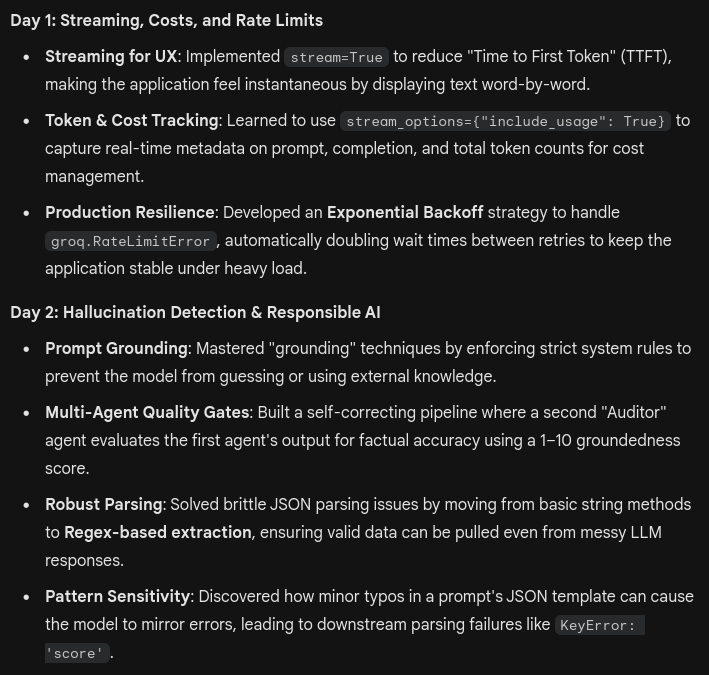